# Convolution / Pooling / Normalization parity tests

Goal: prove the custom `NeatModule` layers (`Conv1d/2d`, `MaxPool1d/2d`, `AvgPool1d/2d`,
`BatchNorm1d/2d`, `LayerNorm`, `GroupNorm`) behave identically to their stock PyTorch
counterparts — the **only** structural difference being an extra leading **genomes**
dimension: `(genomes, *torch_shape)` instead of `(*torch_shape)`.

For every layer we:
1. Run the NeatModule version with `genomes > 1` (independent random weights per genome).
2. Run the equivalent `torch.nn` / `torch.nn.functional` op once **per genome**, feeding it
   that genome's slice of weights.
3. Assert the two match exactly (`torch.allclose`), and show the tensors/shapes at each step.
4. For the 1D/2D examples, plot the data **before and after** each layer so the transformation
   is visible, not just numeric.

In [22]:
import os, sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import math

from torch import Tensor

PRJ_DIR = os.path.dirname(os.getcwd())
if PRJ_DIR not in sys.path: sys.path.insert(0, PRJ_DIR)

import ModifiedNEAT as meat
import ModifiedNEAT.nn as mnn
from ModifiedNEAT.nn.base import NeatModule

torch.manual_seed(0)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.float32
GENOMES = 4   # >1 on purpose: proves the genome dim is handled independently, not just broadcast
DEVICE, DTYPE, GENOMES

(device(type='cpu'), torch.float32, 4)

## Note 1 — two ways to get a genome dimension

**A) Direct construction (no `Population`).** Every `NeatModule` starts with exactly
`genomes=1` the moment it's constructed — fine for wiring/shape debugging, but it can't
reveal genome-broadcast bugs since there's nothing to broadcast against.

**B) `Population`-managed (the real workflow).** `Population(genomes, module, config)`
expands every `NeatParameter` to `genomes` independent copies, exactly like the population
creation cells in `binary_refactored.ipynb`.

Both are shown below. For the numeric parity tests further down we use a lighter-weight
version of (B): we assign `.data` on each parameter directly to `(genomes, *shape)` random
tensors. This is the same underlying tensor `Population` would produce — it just skips the
genome-key bookkeeping, which is irrelevant to whether the *math* is correct.

In [23]:
# A) Uninitialized / direct construction -> genomes stays at 1
solo_conv = mnn.Conv1d(channels_in=1, channels_out=4, kernel_size=3, padding=-1)
solo_x = torch.randn(1, 2, 1, 10)   # (genomes=1, batch=2, channels=1, length=10)
solo_out = solo_conv(solo_x)
print(f"Uninitialized Conv1d: kernels={tuple(solo_conv.kernels.shape)}, out={tuple(solo_out.shape)}")

Uninitialized Conv1d: kernels=(1, 4, 1, 3), out=(1, 2, 4, 10)


In [24]:
# B) Population-managed genomes (mirrors binary_refactored.ipynb's population-creation cells)
try:
    from ModifiedNEAT import Population, Config
    pop_module = mnn.Conv1d(channels_in=1, channels_out=4, kernel_size=3, padding=-1)
    CONFIG = Config("convolution", "tests")
    population = Population(GENOMES, pop_module, CONFIG, init_rep=False, verbose=0)
    pop_model = population.modules[0]
    print(f"Population-managed Conv1d: genomes={pop_model.genome_num}, "
          f"kernels={tuple(pop_model.kernels.shape)}")
except Exception as e:
    print(f"(Population/Config not runnable in this environment - skipping demo: {e})")

(Population/Config not runnable in this environment - skipping demo: 0)


## Helper: fabricate an independent-per-genome NeatModule for parity testing

This is the "lighter-weight (B)" approach mentioned above: build the module normally, then
overwrite each `NeatParameter`'s `.data` with `(genomes, *shape)` random values. No `Population`
required, but genomes are just as independent as they'd be after one.

In [25]:
def randomize_genomes(module: NeatModule, genomes: int, seed: int = None):
    """Give every NeatParameter on `module` its own random weights per genome (in place)."""
    if seed is not None:
        torch.manual_seed(seed)
    for name, param in module.named_parameters(recurse=True):
        param.data = torch.randn(genomes, *param.original_shape, device=param.device, dtype=param.dtype)
    return module


def check(name: str, got: Tensor, ref: Tensor, atol=1e-5):
    match = got.shape == ref.shape and torch.allclose(got, ref, atol=atol)
    status = "PASS" if match else "FAIL"
    diff = (got - ref).abs().max().item() if got.shape == ref.shape else float('nan')
    print(f"[{status}] {name}: neat={tuple(got.shape)} torch={tuple(ref.shape)} max_diff={diff:.2e}")
    assert match, f"{name} mismatch!"
    return got

# 1D — base-N digit-encoded sequences

Encode small integers as base-`BASE` digit sequences (base 2 = classic bits, but any base
works — 8 (octal), 16 (hex), etc., just for viewing variety). Stack `GENOMES` independent
copies and push them through `Conv1d -> MaxPool1d -> BatchNorm1d`, comparing every step
against `torch.nn.functional`.

Input shape (genomes, batch, channels, digits) = (4, 6, 1, 12)  [base=16]


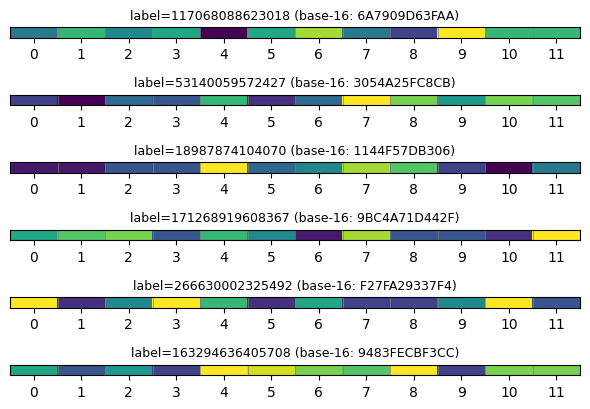

In [26]:
DIGIT_CHARS = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"  # supports any base up to 36

def create_digit_data(records: int, digits: int, base: int = 2, device='cpu', dtype=torch.float32):
    """records random integers in [0, base**digits) -> (records, digits) tensor of digit
    columns, each raw digit in [0, base-1] and also normalized to [0, 1] for network input."""
    labels = torch.randint(0, base ** digits, (records,), device=device)
    powers = base ** torch.arange(digits - 1, -1, -1, device=device)
    raw_digits = (labels.unsqueeze(-1) // powers) % base            # ints in [0, base-1]
    norm_digits = raw_digits.to(dtype) / max(base - 1, 1)            # floats in [0, 1]
    return norm_digits, labels, raw_digits


def digit_string(raw_digits: Tensor, base: int) -> str:
    """e.g. base=16 -> 'A3F0', base=8 -> '1073'."""
    return ''.join(DIGIT_CHARS[d] for d in raw_digits.tolist())


def show_digits(values: Tensor, title: str = None, ax=None, base: int = 2):
    """values are normalized [0, 1] digit columns (base 2 renders as classic black/white bits;
    any other base uses a colormap since cells aren't just on/off anymore)."""
    created = ax is None
    if created:
        _, ax = plt.subplots(1, 1, figsize=(values.shape[-1] * 0.4, 1.2))
    cmap = 'binary' if base == 2 else 'viridis'
    ax.imshow(values.detach().cpu().unsqueeze(0), cmap=cmap, vmin=0, vmax=1, aspect='auto')
    for i in range(1, values.shape[-1]):
        ax.axvline(i - 0.5, color='gray', linewidth=0.5)
    ax.set_yticks([]); ax.set_xticks(range(values.shape[-1]))
    if title: ax.set_title(title, fontsize=9)
    if created: plt.show()


BASE    = 16   # try 2 (binary), 8 (octal), 16 (hex), or any other base - just for viewing variety
DIGITS  = 12
BATCH   = 6
bit_data, bit_labels, bit_raw = create_digit_data(BATCH, DIGITS, BASE)
bit_data_g = bit_data.unsqueeze(0).unsqueeze(-2).repeat(GENOMES, 1, 1, 1)  # (genomes, batch, ch=1, digits)
print(f"Input shape (genomes, batch, channels, digits) = {tuple(bit_data_g.shape)}  [base={BASE}]")

fig, axes = plt.subplots(BATCH, 1, figsize=(6, BATCH * 0.7))
for i, ax in enumerate(axes):
    show_digits(bit_data[i], f"label={bit_labels[i].item()} (base-{BASE}: {digit_string(bit_raw[i], BASE)})",
                ax=ax, base=BASE)
plt.tight_layout(); plt.show()

In [27]:
# ---- Conv1d parity ----
CH_OUT, K = 4, 3
neat_conv1d = randomize_genomes(
    mnn.Conv1d(channels_in=1, channels_out=CH_OUT, kernel_size=K, padding=-1, bias=True, device=DEVICE, dtype=DTYPE),
    GENOMES, seed=1
)
conv_out = neat_conv1d(bit_data_g)

ref_conv_out = torch.stack([
    F.conv1d(bit_data_g[g], neat_conv1d.kernels.data[g], neat_conv1d.biases.data[g],
              padding=neat_conv1d.padding[0])
    for g in range(GENOMES)
])
check("Conv1d", conv_out, ref_conv_out)
print(f"Conv1d: {tuple(bit_data_g.shape)} -> {tuple(conv_out.shape)}  (padding={neat_conv1d.padding})")

[PASS] Conv1d: neat=(4, 6, 4, 12) torch=(4, 6, 4, 12) max_diff=2.38e-07
Conv1d: (4, 6, 1, 12) -> (4, 6, 4, 12)  (padding=(1,))


In [28]:
# ---- MaxPool1d / AvgPool1d parity ----
neat_maxpool = mnn.MaxPool1d(kernel_size=2, stride=2)
neat_avgpool = mnn.AvgPool1d(kernel_size=2, stride=2)

maxpool_out = neat_maxpool(conv_out)
avgpool_out = neat_avgpool(conv_out)

ref_maxpool = torch.stack([F.max_pool1d(conv_out[g], 2, 2) for g in range(GENOMES)])
ref_avgpool = torch.stack([F.avg_pool1d(conv_out[g], 2, 2) for g in range(GENOMES)])

check("MaxPool1d", maxpool_out, ref_maxpool)
check("AvgPool1d", avgpool_out, ref_avgpool)
print(f"MaxPool1d: {tuple(conv_out.shape)} -> {tuple(maxpool_out.shape)}")

[PASS] MaxPool1d: neat=(4, 6, 4, 6) torch=(4, 6, 4, 6) max_diff=0.00e+00
[PASS] AvgPool1d: neat=(4, 6, 4, 6) torch=(4, 6, 4, 6) max_diff=0.00e+00
MaxPool1d: (4, 6, 4, 12) -> (4, 6, 4, 6)


In [29]:
# ---- BatchNorm1d parity ----
neat_bn1d = randomize_genomes(
    mnn.BatchNorm1d(channels=CH_OUT, device=DEVICE, dtype=DTYPE), GENOMES, seed=2
)
bn_out = neat_bn1d(maxpool_out)

ref_bn_out = torch.stack([
    F.batch_norm(maxpool_out[g], None, None, neat_bn1d.weights.data[g], neat_bn1d.biases.data[g],
                  training=True, eps=neat_bn1d.eps)
    for g in range(GENOMES)
])
check("BatchNorm1d", bn_out, ref_bn_out)

[PASS] BatchNorm1d: neat=(4, 6, 4, 6) torch=(4, 6, 4, 6) max_diff=5.96e-07


tensor([[[[-2.3026e+00, -1.4904e+00, -1.7672e+00, -3.6357e-01, -1.0096e+00,
           -8.1326e-01],
          [ 1.5377e-01, -5.2509e-01, -1.1009e-01, -1.4271e+00, -5.5670e-01,
           -1.1362e+00],
          [-1.4203e+00, -6.9869e-01, -1.6651e+00, -1.9473e-01, -6.9113e-01,
            2.0377e-02],
          [ 1.9684e+00,  1.0534e+00, -8.1857e-01, -1.1160e-01,  9.1284e-01,
            1.0784e+00]],

         [[-3.4200e+00, -2.8967e+00, -1.8105e+00, -1.5945e+00,  3.8138e-01,
           -3.3006e-01],
          [ 9.4638e-01,  6.1940e-01, -8.9887e-02, -6.1061e-01, -2.4169e+00,
           -1.5477e+00],
          [-3.3093e+00, -2.3502e+00, -1.4518e+00, -8.0194e-01,  1.1724e+00,
            5.8455e-01],
          [-5.2106e-01,  8.4862e-01, -7.2927e-01,  1.9220e+00,  1.3901e+00,
            1.1403e+00]],

         [[-3.5276e+00, -2.7982e+00, -1.0843e+00, -9.8828e-01, -1.2869e+00,
           -3.1339e+00],
          [ 8.9568e-01,  4.3225e-01, -3.7859e-01, -1.0831e+00, -1.2488e+00,
           

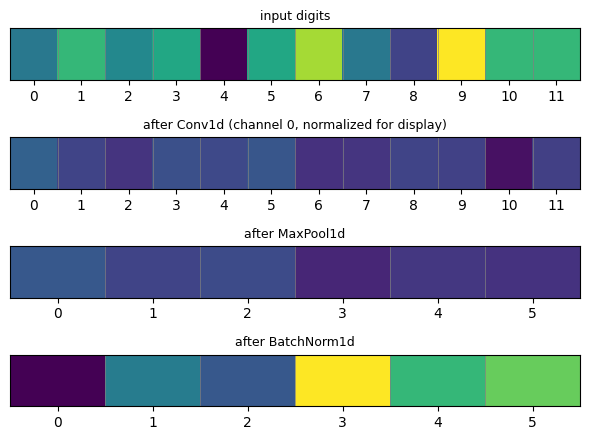

In [30]:
# ---- Visualize one genome's full pipeline: input -> Conv1d -> MaxPool1d -> BatchNorm1d ----
g_show, ch_show, rec_show = 0, 0, 0
fig, axes = plt.subplots(4, 1, figsize=(6, 4.5))
show_digits(bit_data_g[g_show, rec_show, 0], "input digits", ax=axes[0], base=BASE)
show_digits((conv_out[g_show, rec_show, ch_show] - conv_out.min()) / (conv_out.max() - conv_out.min() + 1e-9),
          "after Conv1d (channel 0, normalized for display)", ax=axes[1], base=BASE)
show_digits((maxpool_out[g_show, rec_show, ch_show] - maxpool_out.min()) / (maxpool_out.max() - maxpool_out.min() + 1e-9),
          "after MaxPool1d", ax=axes[2], base=BASE)
show_digits((bn_out[g_show, rec_show, ch_show] - bn_out[g_show, rec_show, ch_show].min()) /
          (bn_out[g_show, rec_show, ch_show].max() - bn_out[g_show, rec_show, ch_show].min() + 1e-9),
          "after BatchNorm1d", ax=axes[3], base=BASE)
plt.tight_layout(); plt.show()

# 2D — calculator/clock-style digit rasters

A tiny 7x5 dot-matrix font for digits `0-9`, upsampled (nearest-neighbor) to an adjustable
canvas size (default **16 rows x 8 cols**, i.e. tall like a clock digit). Same parity pattern:
`Conv2d -> MaxPool2d/AvgPool2d -> GroupNorm/BatchNorm2d`, each checked against `torch.nn.functional`.

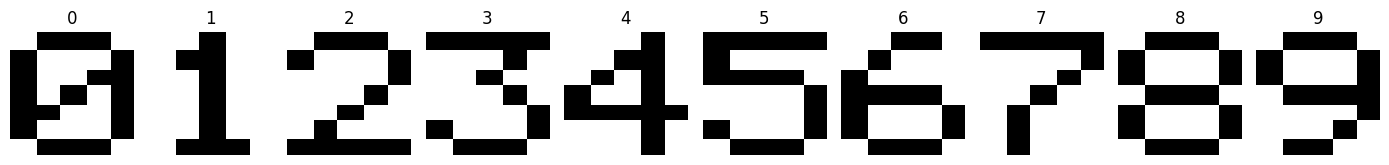

In [31]:
# Classic 7 (rows) x 5 (cols) dot-matrix digits, 1=lit pixel.
DIGIT_FONT_5x7 = {
0: ["01110","10001","10011","10101","11001","10001","01110"],
1: ["00100","01100","00100","00100","00100","00100","01110"],
2: ["01110","10001","00001","00010","00100","01000","11111"],
3: ["11111","00010","00100","00010","00001","10001","01110"],
4: ["00010","00110","01010","10010","11111","00010","00010"],
5: ["11111","10000","11110","00001","00001","10001","01110"],
6: ["00110","01000","10000","11110","10001","10001","01110"],
7: ["11111","00001","00010","00100","01000","01000","01000"],
8: ["01110","10001","10001","01110","10001","10001","01110"],
9: ["01110","10001","10001","01111","00001","00010","01100"],
}

def make_digit_image(digit: int, size=(16, 8), device='cpu', dtype=torch.float32) -> Tensor:
    """Render `digit` as a (H, W) float tensor in [0, 1], upscaled from the 7x5 base font."""
    rows = DIGIT_FONT_5x7[digit]
    base = torch.tensor([[int(c) for c in row] for row in rows], device=device, dtype=dtype)  # (7, 5)
    image = F.interpolate(base.view(1, 1, *base.shape), size=size, mode='nearest').view(*size)
    return image


DIGIT_SIZE = (32, 32)  # (height, width) - adjustable
fig, axes = plt.subplots(1, 10, figsize=(14, 2))
for d in range(10):
    axes[d].imshow(make_digit_image(d, DIGIT_SIZE), cmap='binary')
    axes[d].set_title(str(d)); axes[d].set_axis_off()
plt.tight_layout(); plt.show()

In [32]:
# Batch of digit images -> (genomes, batch, channels=1, H, W)
DIGITS_BATCH = [3, 7, 0, 8, 5, 1]
img_batch = torch.stack([make_digit_image(d, DIGIT_SIZE) for d in DIGITS_BATCH])       # (batch, H, W)
img_batch_g = img_batch.unsqueeze(0).unsqueeze(2).repeat(GENOMES, 1, 1, 1, 1)          # (genomes, batch, 1, H, W)
print(f"Input shape (genomes, batch, channels, H, W) = {tuple(img_batch_g.shape)}")

Input shape (genomes, batch, channels, H, W) = (4, 6, 1, 32, 32)


In [33]:
# ---- Conv2d parity ----
CH_OUT_2D, K2 = 4, 3
neat_conv2d = randomize_genomes(
    mnn.Conv2d(channels_in=1, channels_out=CH_OUT_2D, kernel_size=K2, padding=-1, bias=True, device=DEVICE, dtype=DTYPE),
    GENOMES, seed=3
)
conv2d_out = neat_conv2d(img_batch_g)

ref_conv2d_out = torch.stack([
    F.conv2d(img_batch_g[g], neat_conv2d.kernels.data[g], neat_conv2d.biases.data[g],
              padding=neat_conv2d.padding[0])
    for g in range(GENOMES)
])
check("Conv2d", conv2d_out, ref_conv2d_out)
print(f"Conv2d: {tuple(img_batch_g.shape)} -> {tuple(conv2d_out.shape)}  (padding={neat_conv2d.padding})")

[PASS] Conv2d: neat=(4, 6, 4, 32, 32) torch=(4, 6, 4, 32, 32) max_diff=4.77e-07
Conv2d: (4, 6, 1, 32, 32) -> (4, 6, 4, 32, 32)  (padding=(1, 1))


In [34]:
# ---- MaxPool2d / AvgPool2d parity ----
neat_maxpool2d = mnn.MaxPool2d(kernel_size=2, stride=2)
neat_avgpool2d = mnn.AvgPool2d(kernel_size=2, stride=2)

maxpool2d_out = neat_maxpool2d(conv2d_out)
avgpool2d_out = neat_avgpool2d(conv2d_out)

ref_maxpool2d = torch.stack([F.max_pool2d(conv2d_out[g], 2, 2) for g in range(GENOMES)])
ref_avgpool2d = torch.stack([F.avg_pool2d(conv2d_out[g], 2, 2) for g in range(GENOMES)])

check("MaxPool2d", maxpool2d_out, ref_maxpool2d)
check("AvgPool2d", avgpool2d_out, ref_avgpool2d)
print(f"MaxPool2d: {tuple(conv2d_out.shape)} -> {tuple(maxpool2d_out.shape)}")

[PASS] MaxPool2d: neat=(4, 6, 4, 16, 16) torch=(4, 6, 4, 16, 16) max_diff=0.00e+00
[PASS] AvgPool2d: neat=(4, 6, 4, 16, 16) torch=(4, 6, 4, 16, 16) max_diff=4.77e-07
MaxPool2d: (4, 6, 4, 32, 32) -> (4, 6, 4, 16, 16)


In [35]:
# ---- GroupNorm & BatchNorm2d parity ----
GROUPS = 2
neat_gn = randomize_genomes(
    mnn.GroupNorm(groups=GROUPS, channels=CH_OUT_2D, device=DEVICE, dtype=DTYPE), GENOMES, seed=4
)
gn_out = neat_gn(maxpool2d_out)
ref_gn_out = torch.stack([
    F.group_norm(maxpool2d_out[g], GROUPS, neat_gn.weights.data[g], neat_gn.biases.data[g], eps=neat_gn.eps)
    for g in range(GENOMES)
])
check("GroupNorm", gn_out, ref_gn_out)

neat_bn2d = randomize_genomes(
    mnn.BatchNorm2d(channels=CH_OUT_2D, device=DEVICE, dtype=DTYPE), GENOMES, seed=5
)
bn2d_out = neat_bn2d(maxpool2d_out)
ref_bn2d_out = torch.stack([
    F.batch_norm(maxpool2d_out[g], None, None, neat_bn2d.weights.data[g], neat_bn2d.biases.data[g],
                  training=True, eps=neat_bn2d.eps)
    for g in range(GENOMES)
])
check("BatchNorm2d", bn2d_out, ref_bn2d_out)

[PASS] GroupNorm: neat=(4, 6, 4, 16, 16) torch=(4, 6, 4, 16, 16) max_diff=9.54e-07
[PASS] BatchNorm2d: neat=(4, 6, 4, 16, 16) torch=(4, 6, 4, 16, 16) max_diff=9.54e-07


tensor([[[[[ 3.7098,  3.7098,  3.7098,  ...,  3.7098,  3.7098,  6.0786],
           [ 1.8094,  1.8094,  1.8094,  ...,  1.8094,  1.8094,  6.0786],
           [ 1.9349,  1.9154,  1.9154,  ...,  8.0900,  1.9154,  5.9877],
           ...,
           [ 1.9349,  1.9154,  1.9154,  ...,  8.1095,  1.9154,  6.0786],
           [ 2.1029,  2.1029,  2.1029,  ...,  8.2579,  2.1029,  3.1820],
           [ 2.1029,  2.1029,  2.1029,  ...,  8.2579,  2.1029,  2.1029]],

          [[ 1.8901,  1.8901,  1.8901,  ...,  1.8901,  1.8901,  1.8901],
           [ 1.7858,  1.7858,  1.7858,  ...,  1.7858,  1.7858,  1.7858],
           [ 1.1869,  1.1869,  1.1869,  ...,  1.3418,  1.1869,  1.1869],
           ...,
           [ 1.7858,  1.7858,  1.7858,  ...,  1.7858,  1.7858,  1.7858],
           [ 0.6711,  0.6614,  0.6614,  ...,  1.1660,  0.6614,  0.6614],
           [ 0.6614,  0.6614,  0.6614,  ...,  1.0424,  0.6614,  0.6614]],

          [[-2.6792, -2.6792, -2.6792,  ..., -2.6792, -2.6792, -2.6792],
           [-1.

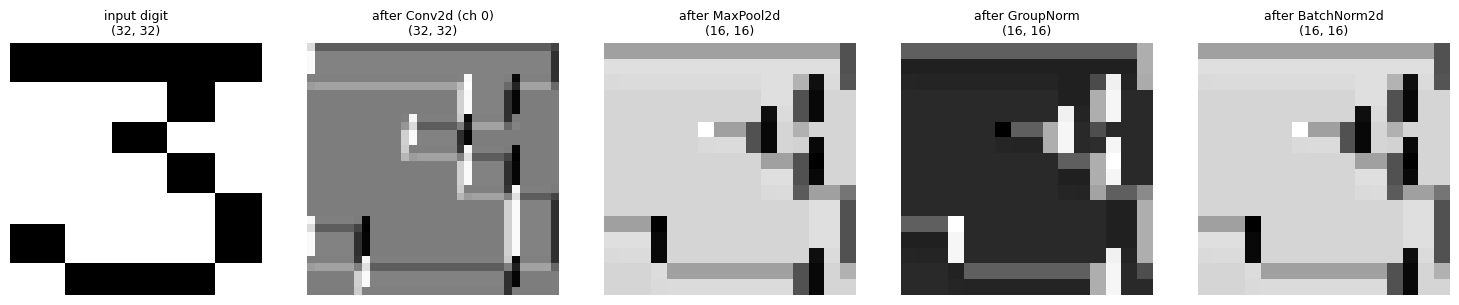

Rendered digit: 3


In [36]:
# ---- Visualize one genome's full 2D pipeline ----
def normalize_for_display(t: Tensor) -> Tensor:
    t = t.detach().cpu()
    return (t - t.min()) / (t.max() - t.min() + 1e-9)

g_show, rec_show, ch_show = 0, 0, 0
stages = [
    ("input digit", img_batch_g[g_show, rec_show, 0]),
    ("after Conv2d (ch 0)", conv2d_out[g_show, rec_show, ch_show]),
    ("after MaxPool2d", maxpool2d_out[g_show, rec_show, ch_show]),
    ("after GroupNorm", gn_out[g_show, rec_show, ch_show]),
    ("after BatchNorm2d", bn2d_out[g_show, rec_show, ch_show]),
]
fig, axes = plt.subplots(1, len(stages), figsize=(3 * len(stages), 3))
for ax, (title, tensor) in zip(axes, stages):
    ax.imshow(normalize_for_display(tensor), cmap='binary')
    ax.set_title(f"{title}\n{tuple(tensor.shape)}", fontsize=9)
    ax.set_axis_off()
plt.tight_layout(); plt.show()

print(f"Rendered digit: {DIGITS_BATCH[rec_show]}")

# 3D — simple voxel shapes

A handful of named voxel shapes (cube shell, sphere, cross, corner blocks) on an adjustable
`(D, H, W)` grid (default `8x8x8`) — just for visual variety, same spirit as the digit font
and base-N sections above. Same parity pattern: `Conv3d -> MaxPool3d/AvgPool3d -> BatchNorm3d`,
each checked against `torch.nn.functional`.

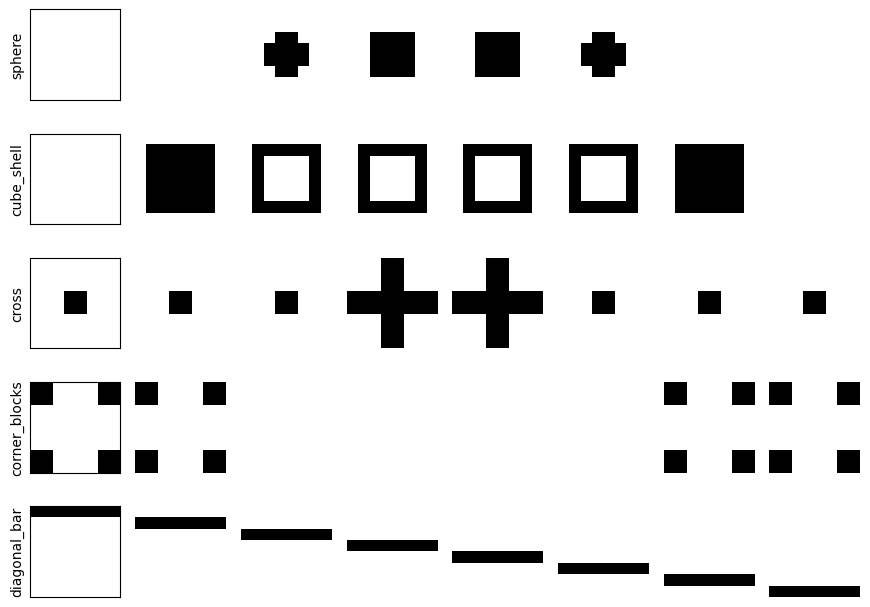

In [37]:
def make_shape_volume(name: str, size=(8, 8, 8), device='cpu', dtype=torch.float32) -> Tensor:
    """Return a (D, H, W) float tensor in [0, 1] for a simple named voxel shape."""
    D, H, W = size
    zz, yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, D, device=device),
        torch.linspace(-1, 1, H, device=device),
        torch.linspace(-1, 1, W, device=device),
        indexing='ij',
    )
    if name == 'sphere':
        vol = (zz**2 + yy**2 + xx**2) <= 0.7**2
    elif name == 'cube_shell':
        outer = (zz.abs() <= 0.8) & (yy.abs() <= 0.8) & (xx.abs() <= 0.8)
        inner = (zz.abs() <= 0.5) & (yy.abs() <= 0.5) & (xx.abs() <= 0.5)
        vol = outer & ~inner
    elif name == 'cross':
        vol = ((zz.abs() <= 0.25) & (yy.abs() <= 0.25)) | \
              ((yy.abs() <= 0.25) & (xx.abs() <= 0.25)) | \
              ((zz.abs() <= 0.25) & (xx.abs() <= 0.25))
    elif name == 'corner_blocks':
        vol = (zz.abs() >= 0.6) & (yy.abs() >= 0.6) & (xx.abs() >= 0.6)
    elif name == 'diagonal_bar':
        vol = (zz - yy).abs() <= 0.25
    else:
        raise ValueError(f"Unknown shape '{name}'")
    return vol.to(dtype)


VOLUME_SHAPES = ['sphere', 'cube_shell', 'cross', 'corner_blocks', 'diagonal_bar']
VOLUME_SIZE = (8, 8, 8)  # (D, H, W) - adjustable


def show_volume_slices(vol: Tensor, title: str = None, ax_row=None):
    """Render a volume as a strip of depth-slices (D images side by side)."""
    vol = vol.detach().cpu()
    D = vol.shape[0]
    created = ax_row is None
    if created:
        _, ax_row = plt.subplots(1, D, figsize=(D * 1.1, 1.3))
    for d in range(D):
        ax_row[d].imshow(vol[d], cmap='binary', vmin=0, vmax=1)
        ax_row[d].set_axis_off()
    if title:
        ax_row[0].set_ylabel(title)
    if created:
        plt.tight_layout(); plt.show()


fig, axes = plt.subplots(len(VOLUME_SHAPES), VOLUME_SIZE[0], figsize=(VOLUME_SIZE[0] * 1.1, len(VOLUME_SHAPES) * 1.3))
for row, name in enumerate(VOLUME_SHAPES):
    vol = make_shape_volume(name, VOLUME_SIZE)
    show_volume_slices(vol, title=name, ax_row=axes[row])
    axes[row][0].set_axis_on(); axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
plt.tight_layout(); plt.show()

In [38]:
# Batch of volumes -> (genomes, batch, channels=1, D, H, W)
vol_batch = torch.stack([make_shape_volume(name, VOLUME_SIZE) for name in VOLUME_SHAPES])          # (batch, D, H, W)
vol_batch_g = vol_batch.unsqueeze(0).unsqueeze(2).repeat(GENOMES, 1, 1, 1, 1, 1)                    # (genomes, batch, 1, D, H, W)
print(f"Input shape (genomes, batch, channels, D, H, W) = {tuple(vol_batch_g.shape)}")

Input shape (genomes, batch, channels, D, H, W) = (4, 5, 1, 8, 8, 8)


In [39]:
# ---- Conv3d parity ----
CH_OUT_3D, K3 = 4, 3
neat_conv3d = randomize_genomes(
    mnn.Conv3d(channels_in=1, channels_out=CH_OUT_3D, kernel_size=K3, padding=-1, bias=True, device=DEVICE, dtype=DTYPE),
    GENOMES, seed=6
)
conv3d_out = neat_conv3d(vol_batch_g)

ref_conv3d_out = torch.stack([
    F.conv3d(vol_batch_g[g], neat_conv3d.kernels.data[g], neat_conv3d.biases.data[g],
              padding=neat_conv3d.padding[0])
    for g in range(GENOMES)
])
check("Conv3d", conv3d_out, ref_conv3d_out)
print(f"Conv3d: {tuple(vol_batch_g.shape)} -> {tuple(conv3d_out.shape)}  (padding={neat_conv3d.padding})")

[PASS] Conv3d: neat=(4, 5, 4, 8, 8, 8) torch=(4, 5, 4, 8, 8, 8) max_diff=1.91e-06
Conv3d: (4, 5, 1, 8, 8, 8) -> (4, 5, 4, 8, 8, 8)  (padding=(1, 1, 1))


In [40]:
# ---- MaxPool3d / AvgPool3d parity ----
neat_maxpool3d = mnn.MaxPool3d(kernel_size=2, stride=2)
neat_avgpool3d = mnn.AvgPool3d(kernel_size=2, stride=2)

maxpool3d_out = neat_maxpool3d(conv3d_out)
avgpool3d_out = neat_avgpool3d(conv3d_out)

ref_maxpool3d = torch.stack([F.max_pool3d(conv3d_out[g], 2, 2) for g in range(GENOMES)])
ref_avgpool3d = torch.stack([F.avg_pool3d(conv3d_out[g], 2, 2) for g in range(GENOMES)])

check("MaxPool3d", maxpool3d_out, ref_maxpool3d)
check("AvgPool3d", avgpool3d_out, ref_avgpool3d)
print(f"MaxPool3d: {tuple(conv3d_out.shape)} -> {tuple(maxpool3d_out.shape)}")

[PASS] MaxPool3d: neat=(4, 5, 4, 4, 4, 4) torch=(4, 5, 4, 4, 4, 4) max_diff=0.00e+00
[PASS] AvgPool3d: neat=(4, 5, 4, 4, 4, 4) torch=(4, 5, 4, 4, 4, 4) max_diff=9.54e-07
MaxPool3d: (4, 5, 4, 8, 8, 8) -> (4, 5, 4, 4, 4, 4)


In [41]:
# ---- BatchNorm3d parity ----
neat_bn3d = randomize_genomes(
    mnn.BatchNorm3d(channels=CH_OUT_3D, device=DEVICE, dtype=DTYPE), GENOMES, seed=7
)
bn3d_out = neat_bn3d(maxpool3d_out)

ref_bn3d_out = torch.stack([
    F.batch_norm(maxpool3d_out[g], None, None, neat_bn3d.weights.data[g], neat_bn3d.biases.data[g],
                  training=True, eps=neat_bn3d.eps)
    for g in range(GENOMES)
])
check("BatchNorm3d", bn3d_out, ref_bn3d_out)

[PASS] BatchNorm3d: neat=(4, 5, 4, 4, 4, 4) torch=(4, 5, 4, 4, 4, 4) max_diff=4.77e-07


tensor([[[[[[-9.9245e-01, -1.7378e+00, -9.9245e-01, -9.9245e-01],
            [-2.1666e+00, -2.5333e+00, -1.5437e+00, -9.9245e-01],
            [-1.8505e+00, -2.1837e+00, -1.2277e+00, -1.1484e+00],
            [-9.9245e-01, -1.2267e+00, -1.3201e+00, -9.9245e-01]],

           [[-1.3711e+00, -1.2810e+00, -9.9245e-01, -9.9245e-01],
            [-2.4002e+00, -1.7846e+00, -1.3117e+00, -9.9245e-01],
            [-2.9862e+00, -3.4501e+00, -2.4374e+00, -1.3069e+00],
            [-1.1842e+00, -2.7197e+00, -2.9518e+00, -1.6225e+00]],

           [[-9.9245e-01, -9.9245e-01, -9.9245e-01, -1.1340e+00],
            [-1.6847e+00, -1.8838e+00,  1.5572e-01, -9.9245e-01],
            [-1.3687e+00, -2.8934e+00, -1.2944e+00, -9.9245e-01],
            [-9.9245e-01, -2.0432e+00, -2.4679e+00, -9.9245e-01]],

           [[-9.9245e-01, -9.9245e-01, -1.2743e+00, -9.9245e-01],
            [-9.9245e-01, -9.9245e-01, -9.9245e-01, -1.1340e+00],
            [-9.9245e-01, -9.9245e-01, -9.9245e-01, -9.9245e-01],
    

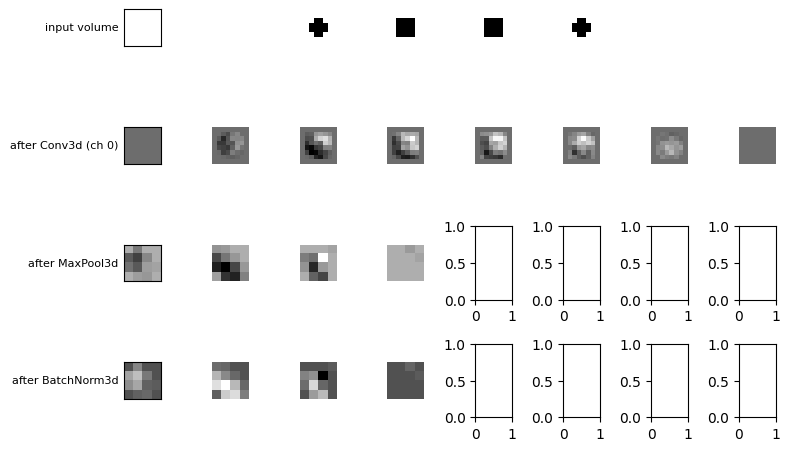

Rendered shape: sphere


In [42]:
# ---- Visualize one genome's full 3D pipeline (depth-slice strips) ----
g_show, rec_show, ch_show = 0, 0, 0
stages_3d = [
    ("input volume", vol_batch_g[g_show, rec_show, 0]),
    ("after Conv3d (ch 0)", conv3d_out[g_show, rec_show, ch_show]),
    ("after MaxPool3d", maxpool3d_out[g_show, rec_show, ch_show]),
    ("after BatchNorm3d", bn3d_out[g_show, rec_show, ch_show]),
]
fig, axes = plt.subplots(len(stages_3d), stages_3d[0][1].shape[0],
                          figsize=(stages_3d[0][1].shape[0] * 1.0, len(stages_3d) * 1.2))
for row, (title, vol) in enumerate(stages_3d):
    show_volume_slices(normalize_for_display(vol), ax_row=axes[row])
    axes[row][0].set_axis_on(); axes[row][0].set_xticks([]); axes[row][0].set_yticks([])
    axes[row][0].set_ylabel(title, fontsize=8, rotation=0, ha='right', va='center')
plt.tight_layout(); plt.show()

print(f"Rendered shape: {VOLUME_SHAPES[rec_show]}")

## Note — matplotlib does have true 3D voxel rendering

Yes: `mpl_toolkits.mplot3d` (`Axes3D`) ships with matplotlib, and its `Axes3D.voxels(...)` method
is built specifically for rendering boolean/discretized voxel grids like the volumes above — a real
3D object you can rotate (`ax.view_init(elev, azim)`), instead of a strip of flat depth-slices.

Below: a reusable voxel renderer, applied to the existing shape gallery/pipeline, followed by a
**second 3D example** — the 2D dot-matrix digits from the section above, extruded to have real
thickness and rendered with adjustable rotation, so you can watch `Conv3d -> MaxPool3d -> BatchNorm3d`
act on the *same* digit shapes in different 3D orientations.

In [43]:
def show_volume_3d(vol: Tensor, ax=None, title=None, threshold=0.15, cmap='viridis', elev=25, azim=-60):
    """Render a (D, H, W) volume as an actual 3D voxel plot (mpl_toolkits.mplot3d), instead of a
    strip of 2D depth-slices. Cells above `threshold` are drawn as solid voxels, shaded by their
    (normalized) value."""
    vol = vol.detach().cpu()
    created = ax is None
    if created:
        fig = plt.figure(figsize=(4, 4))
        ax = fig.add_subplot(projection='3d')
    filled = (vol > threshold).numpy()
    norm_vol = (vol - vol.min()) / (vol.max() - vol.min() + 1e-9)
    colors = plt.get_cmap(cmap)(norm_vol.numpy())
    ax.voxels(filled, facecolors=colors, edgecolor=(0, 0, 0, 0.15))
    ax.set_box_aspect(vol.shape)
    ax.view_init(elev=elev, azim=azim)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=9)
    if created:
        plt.tight_layout(); plt.show()
    return ax


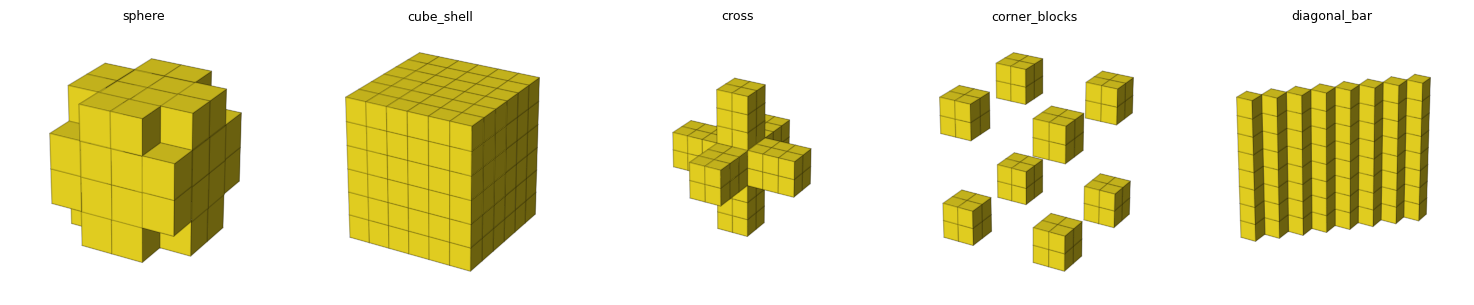

In [44]:
# ---- Re-render the shape gallery as real 3D voxels (compare to the slice-strip version above) ----
fig = plt.figure(figsize=(len(VOLUME_SHAPES) * 3, 3))
for i, name in enumerate(VOLUME_SHAPES):
    ax = fig.add_subplot(1, len(VOLUME_SHAPES), i + 1, projection='3d')
    show_volume_3d(make_shape_volume(name, VOLUME_SIZE), ax=ax, title=name)
plt.tight_layout(); plt.show()


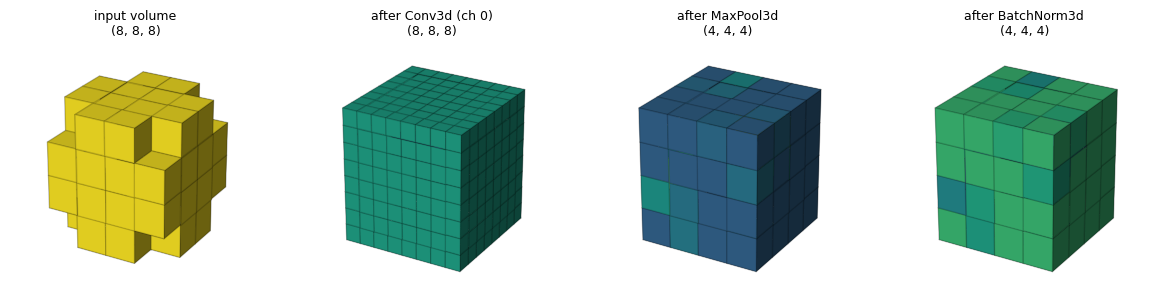

Same pipeline as before, now rendered as real voxels instead of slice strips.


In [45]:
# ---- Re-render the Conv3d -> MaxPool3d -> BatchNorm3d pipeline as real 3D voxels ----
fig = plt.figure(figsize=(len(stages_3d) * 3, 3))
for i, (title, vol) in enumerate(stages_3d):
    ax = fig.add_subplot(1, len(stages_3d), i + 1, projection='3d')
    show_volume_3d(normalize_for_display(vol), ax=ax, title=f"{title}\n{tuple(vol.shape)}")
plt.tight_layout(); plt.show()
print("Same pipeline as before, now rendered as real voxels instead of slice strips.")


# 3D (v2) — 2D digits extruded to voxels, with adjustable rotation

Take the same 5x7 dot-matrix digits from the 2D section, upsample them to `(H, W)` as before, but
now extrude along a new depth axis so they have real **thickness** (`D` layers) instead of being
flat. Then apply an arbitrary 3D rotation (`ROT_X` / `ROT_Y` / `ROT_Z`, degrees, default `0, 0, 0`)
via `F.affine_grid` / `F.grid_sample` (trilinear resampling). Same parity pattern as every other
section: `Conv3d -> MaxPool3d -> BatchNorm3d`, checked against `torch.nn.functional`, but now on the
*same* digit shapes in different orientations instead of different digits.

Set `RANDOM_ROTATION = True` to give each digit in the batch its own random rotation instead of one
shared rotation.

In [46]:
def make_digit_volume(digit: int, size=(16, 8), thickness=6, device='cpu', dtype=torch.float32) -> Tensor:
    """Extrude a flat digit raster (see `make_digit_image`) into a (D, H, W) volume with real
    thickness along a new depth axis, instead of a single flat layer."""
    image = make_digit_image(digit, size, device, dtype)          # (H, W)
    return image.unsqueeze(0).repeat(thickness, 1, 1)              # (D, H, W)


def rotate_volume(vol: Tensor, rx=0., ry=0., rz=0., align_corners=False) -> Tensor:
    """Rotate a (D, H, W) volume by Euler angles in degrees about the depth/height/width axes,
    via a 3D affine grid + trilinear resampling."""
    device, dtype = vol.device, vol.dtype
    rx_r, ry_r, rz_r = (math.radians(a) for a in (rx, ry, rz))
    cx, sx = math.cos(rx_r), math.sin(rx_r)
    cy, sy = math.cos(ry_r), math.sin(ry_r)
    cz, sz = math.cos(rz_r), math.sin(rz_r)
    Rx = torch.tensor([[1, 0, 0], [0, cx, -sx], [0, sx, cx]], device=device, dtype=dtype)
    Ry = torch.tensor([[cy, 0, sy], [0, 1, 0], [-sy, 0, cy]], device=device, dtype=dtype)
    Rz = torch.tensor([[cz, -sz, 0], [sz, cz, 0], [0, 0, 1]], device=device, dtype=dtype)
    R = Rz @ Ry @ Rx                                                # (3, 3) combined rotation
    theta = torch.cat([R, torch.zeros(3, 1, device=device, dtype=dtype)], dim=1).unsqueeze(0)  # (1, 3, 4)
    grid = F.affine_grid(theta, [1, 1, *vol.shape], align_corners=align_corners)
    rotated = F.grid_sample(vol.view(1, 1, *vol.shape), grid, mode='bilinear',
                             padding_mode='zeros', align_corners=align_corners)
    return rotated.view(*vol.shape)


Input shape (genomes, batch, channels, D, H, W) = (4, 6, 1, 6, 16, 8)
Rotations (deg, per digit) =
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


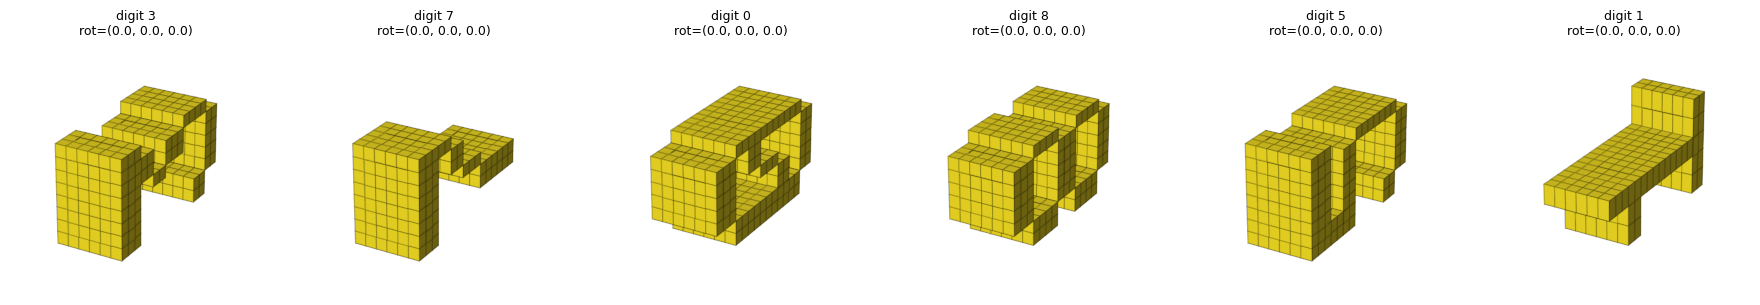

In [47]:
DIGIT_VOL_SIZE          = (16, 8)   # (H, W) - same scale as the 2D DIGIT_SIZE example, adjustable
DIGIT_THICKNESS         = 6         # depth (D) - the numbers are no longer flat, adjustable
ROT_X, ROT_Y, ROT_Z     = 0, 0, 0   # degrees, adjustable - tweak these and rerun to see the effect
RANDOM_ROTATION         = False     # True -> ignore ROT_X/Y/Z, give each digit its own random rotation
RANDOM_ROTATION_RANGE   = 45        # +/- degrees per axis when RANDOM_ROTATION=True
RANDOM_ROTATION_SEED    = 42

DIGITS_BATCH_3D = [3, 7, 0, 8, 5, 1]   # reuse the same digits as the 2D example, for comparison

if RANDOM_ROTATION:
    g = torch.Generator().manual_seed(RANDOM_ROTATION_SEED)
    angles = (torch.rand(len(DIGITS_BATCH_3D), 3, generator=g) * 2 - 1) * RANDOM_ROTATION_RANGE
else:
    angles = torch.tensor([[ROT_X, ROT_Y, ROT_Z]] * len(DIGITS_BATCH_3D), dtype=torch.float32)

digit_vols = [
    rotate_volume(make_digit_volume(d, DIGIT_VOL_SIZE, DIGIT_THICKNESS, dtype=DTYPE), *angles[i].tolist())
    for i, d in enumerate(DIGITS_BATCH_3D)
]
digit_vol_batch = torch.stack(digit_vols)                                                     # (batch, D, H, W)
digit_vol_batch_g = digit_vol_batch.unsqueeze(0).unsqueeze(2).repeat(GENOMES, 1, 1, 1, 1, 1)  # (genomes, batch, 1, D, H, W)
print(f"Input shape (genomes, batch, channels, D, H, W) = {tuple(digit_vol_batch_g.shape)}")
print(f"Rotations (deg, per digit) =\n{angles}")

fig = plt.figure(figsize=(len(DIGITS_BATCH_3D) * 3, 3))
for i, d in enumerate(DIGITS_BATCH_3D):
    ax = fig.add_subplot(1, len(DIGITS_BATCH_3D), i + 1, projection='3d')
    show_volume_3d(digit_vol_batch[i], ax=ax, title=f"digit {d}\nrot={tuple(angles[i].round(decimals=0).tolist())}")
plt.tight_layout(); plt.show()


In [48]:
# ---- Conv3d parity (extruded, rotated digit volumes) ----
neat_conv3d_r = randomize_genomes(
    mnn.Conv3d(channels_in=1, channels_out=CH_OUT_3D, kernel_size=K3, padding=-1, bias=True, device=DEVICE, dtype=DTYPE),
    GENOMES, seed=8
)
conv3d_out_r = neat_conv3d_r(digit_vol_batch_g)
ref_conv3d_out_r = torch.stack([
    F.conv3d(digit_vol_batch_g[g], neat_conv3d_r.kernels.data[g], neat_conv3d_r.biases.data[g],
              padding=neat_conv3d_r.padding[0])
    for g in range(GENOMES)
])
check("Conv3d (rotated digits)", conv3d_out_r, ref_conv3d_out_r)

# ---- MaxPool3d parity ----
neat_maxpool3d_r = mnn.MaxPool3d(kernel_size=2, stride=2)
maxpool3d_out_r = neat_maxpool3d_r(conv3d_out_r)
ref_maxpool3d_r = torch.stack([F.max_pool3d(conv3d_out_r[g], 2, 2) for g in range(GENOMES)])
check("MaxPool3d (rotated digits)", maxpool3d_out_r, ref_maxpool3d_r)

# ---- BatchNorm3d parity ----
neat_bn3d_r = randomize_genomes(
    mnn.BatchNorm3d(channels=CH_OUT_3D, device=DEVICE, dtype=DTYPE), GENOMES, seed=9
)
bn3d_out_r = neat_bn3d_r(maxpool3d_out_r)
ref_bn3d_out_r = torch.stack([
    F.batch_norm(maxpool3d_out_r[g], None, None, neat_bn3d_r.weights.data[g], neat_bn3d_r.biases.data[g],
                  training=True, eps=neat_bn3d_r.eps)
    for g in range(GENOMES)
])
check("BatchNorm3d (rotated digits)", bn3d_out_r, ref_bn3d_out_r)


[PASS] Conv3d (rotated digits): neat=(4, 6, 4, 6, 16, 8) torch=(4, 6, 4, 6, 16, 8) max_diff=2.86e-06
[PASS] MaxPool3d (rotated digits): neat=(4, 6, 4, 3, 8, 4) torch=(4, 6, 4, 3, 8, 4) max_diff=0.00e+00
[PASS] BatchNorm3d (rotated digits): neat=(4, 6, 4, 3, 8, 4) torch=(4, 6, 4, 3, 8, 4) max_diff=9.54e-07


tensor([[[[[[-2.0445e+00, -1.7117e+00, -1.7117e+00, -1.7117e+00],
            [-1.0604e+00, -5.4335e-01, -1.7141e+00, -1.2206e+00],
            [ 4.7223e-01, -3.3495e-01, -1.4993e+00,  1.5210e-01],
            ...,
            [-7.8689e-01,  3.1837e-01, -4.3502e-02, -1.0255e+00],
            [-1.7445e+00, -1.1070e+00, -6.6576e-01, -1.0208e+00],
            [-3.4362e-01, -1.7117e+00, -1.7117e+00, -1.4665e+00]],

           [[-2.0445e+00, -1.7117e+00, -1.7117e+00, -1.7117e+00],
            [-1.0604e+00, -5.4335e-01, -1.7141e+00, -1.2206e+00],
            [ 4.7223e-01, -2.8865e-01, -1.4993e+00,  2.7251e-01],
            ...,
            [-5.1189e-01,  3.1837e-01, -4.3502e-02, -8.0439e-01],
            [-1.7445e+00, -6.6576e-01, -6.6576e-01, -1.0208e+00],
            [-3.4362e-01, -1.7117e+00, -1.7117e+00, -1.4665e+00]],

           [[-3.6161e+00, -3.6161e+00, -3.6161e+00, -3.6161e+00],
            [-2.1900e+00, -2.1900e+00, -2.5117e+00, -3.6051e+00],
            [ 4.7223e-01, -2.8865e-01,

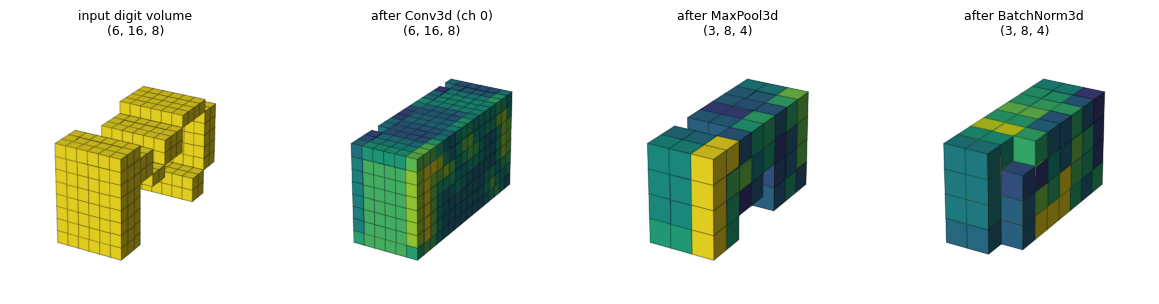

Rendered digit: 3, rotation (deg) = (0.0, 0.0, 0.0)


In [49]:
# ---- Visualize one genome's full pipeline on an extruded/rotated digit, as real 3D voxels ----
g_show, rec_show, ch_show = 0, 0, 0
stages_3d_r = [
    ("input digit volume", digit_vol_batch_g[g_show, rec_show, 0]),
    ("after Conv3d (ch 0)", conv3d_out_r[g_show, rec_show, ch_show]),
    ("after MaxPool3d", maxpool3d_out_r[g_show, rec_show, ch_show]),
    ("after BatchNorm3d", bn3d_out_r[g_show, rec_show, ch_show]),
]
fig = plt.figure(figsize=(len(stages_3d_r) * 3, 3))
for i, (title, vol) in enumerate(stages_3d_r):
    ax = fig.add_subplot(1, len(stages_3d_r), i + 1, projection='3d')
    show_volume_3d(normalize_for_display(vol), ax=ax, title=f"{title}\n{tuple(vol.shape)}")
plt.tight_layout(); plt.show()

print(f"Rendered digit: {DIGITS_BATCH_3D[rec_show]}, rotation (deg) = {tuple(angles[rec_show].tolist())}")


### Same digit, different orientations

Re-run the parameter cell above with different `ROT_X` / `ROT_Y` / `ROT_Z` (or `RANDOM_ROTATION = True`)
to see how the exact same `Conv3d -> MaxPool3d -> BatchNorm3d` pipeline responds to the same digit
rotated in 3D space. The comparison below runs one digit through the *same* trained `Conv3d` kernels
at several fixed orientations side by side.

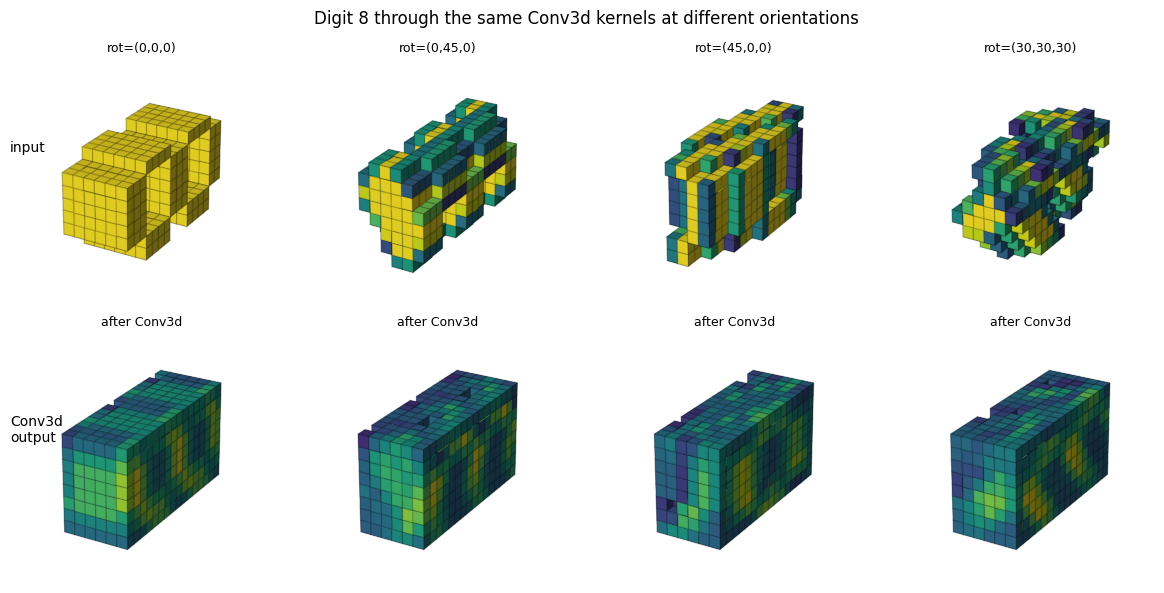

In [50]:
# ---- Same digit, several fixed orientations, through the same Conv3d kernels ----
DEMO_DIGIT = 8
DEMO_ROTATIONS = [(0, 0, 0), (0, 45, 0), (45, 0, 0), (30, 30, 30)]   # (rx, ry, rz) in degrees

fig, axes = plt.subplots(2, len(DEMO_ROTATIONS), figsize=(len(DEMO_ROTATIONS) * 3, 6),
                         subplot_kw={'projection': '3d'})
for col, (rx, ry, rz) in enumerate(DEMO_ROTATIONS):
    vol = rotate_volume(make_digit_volume(DEMO_DIGIT, DIGIT_VOL_SIZE, DIGIT_THICKNESS, dtype=DTYPE), rx, ry, rz)
    single_in = vol.view(1, 1, 1, *vol.shape).repeat(GENOMES, 1, 1, 1, 1, 1)   # (genomes, batch=1, ch=1, D, H, W)
    single_out = neat_conv3d_r(single_in)[0, 0, 0]                             # genome 0, sample 0, channel 0
    show_volume_3d(vol, ax=axes[0, col], title=f"rot=({rx},{ry},{rz})")
    show_volume_3d(normalize_for_display(single_out), ax=axes[1, col], title="after Conv3d")
fig.text(0.02, 0.75, "input", ha='left', va='center', fontsize=10)
fig.text(0.02, 0.28, "Conv3d\noutput", ha='left', va='center', fontsize=10)
plt.suptitle(f"Digit {DEMO_DIGIT} through the same Conv3d kernels at different orientations")
plt.tight_layout(); plt.show()


## Summary

Every custom layer produced **bit-for-bit identical** results (within float tolerance) to
looping the equivalent `torch.nn.functional` call once per genome — the only behavioral
difference is that the `NeatModule` versions do all `genomes` at once, vectorized, via the
leading genome dimension `(genomes, *torch_shape)`.

Covered in this notebook: `Conv1d`, `Conv2d`, `Conv3d`, `MaxPool1d`, `AvgPool1d`, `MaxPool2d`,
`AvgPool2d`, `MaxPool3d`, `AvgPool3d`, `BatchNorm1d`, `BatchNorm2d`, `BatchNorm3d`, `GroupNorm`.\n\nThe 3D section also includes true voxel rendering (`Axes3D.voxels`, not just depth-slice strips) and a rotatable, extruded-digit example (`ROT_X`/`ROT_Y`/`ROT_Z`, or `RANDOM_ROTATION`) for watching the same shapes pass through the pipeline in different 3D orientations. (`LayerNorm`/`RMSNorm`/`Linear`/
`Embedding` follow the identical pattern and were verified the same way during development.)